In [14]:
%load_ext autoreload
%autoreload 2

import yfinance as yf
import pandas as pd
from io import StringIO
import requests
from requests.adapters import HTTPAdapter
import urllib3
import ssl, certifi
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
import sys

sys.path.append('..')

from utils.stats_tests import pair_adf_test



urllib3.disable_warnings()

session = requests.Session()
session.verify = False

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
t1, t2 = 'MA', 'V'
tickers = [t1, t2]
df = yf.download(
    tickers,
    start='2018-01-01',
    end='2025-01-01',
    auto_adjust=False,
)
df.head()

[*********************100%***********************]  2 of 2 completed


Price        Adj Close                   Close                    High  \
Ticker              MA           V          MA           V          MA   
Date                                                                     
2018-01-02  144.809250  108.111923  151.910004  114.510002  153.410004   
2018-01-03  146.630035  109.188187  153.820007  115.650002  153.979996   
2018-01-04  148.526947  109.594185  155.809998  116.080002  157.399994   
2018-01-05  151.606049  112.218864  159.039993  118.860001  159.039993   
2018-01-08  152.064362  112.672035  159.270004  119.339996  160.479996   

Price                          Low                    Open              \
Ticker               V          MA           V          MA           V   
Date                                                                     
2018-01-02  115.080002  151.119995  113.949997  152.009995  114.570000   
2018-01-03  115.790001  152.160004  114.660004  152.289993  114.949997   
2018-01-04  117.360001  154.320007  116.029999  154.539993  116.250000   
2018-01-05  119.000000  156.190002  116.419998  156.199997  116.989998   
2018-01-08  120.480003  158.080002  118.070000  158.580002  118.610001   

Price        Volume           
Ticker           MA        V  
Date                          
2018-01-02  3168900  6080900  
2018-01-03  3732400  6946100  
2018-01-04  3247200  7805300  
2018-01-05  2747700  8590500  
2018-01-08  3143100  6660700

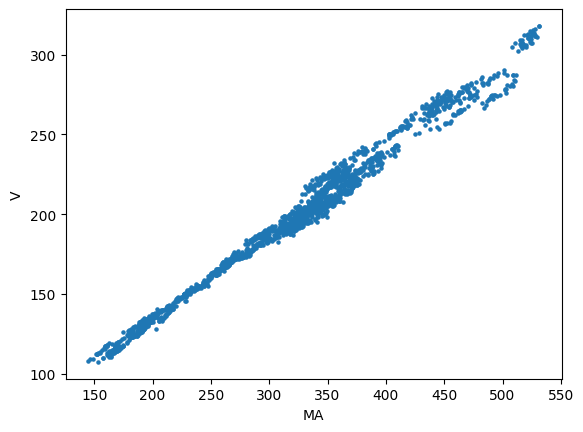

In [39]:
df['Adj Close'].plot(kind='scatter', x=t1, y=t2, marker='.')
plt.show()

In [40]:
y = df['Adj Close'][t2]
x = df['Adj Close'][t1]

x_with_const = sm.add_constant(x)

# x_with_const, y
static_hedge_model = sm.OLS(y, x_with_const).fit()
intercept, beta = static_hedge_model.params.iloc[0], static_hedge_model.params.iloc[1]
intercept, beta

(np.float64(28.637724977518307), np.float64(0.5282583388321934))

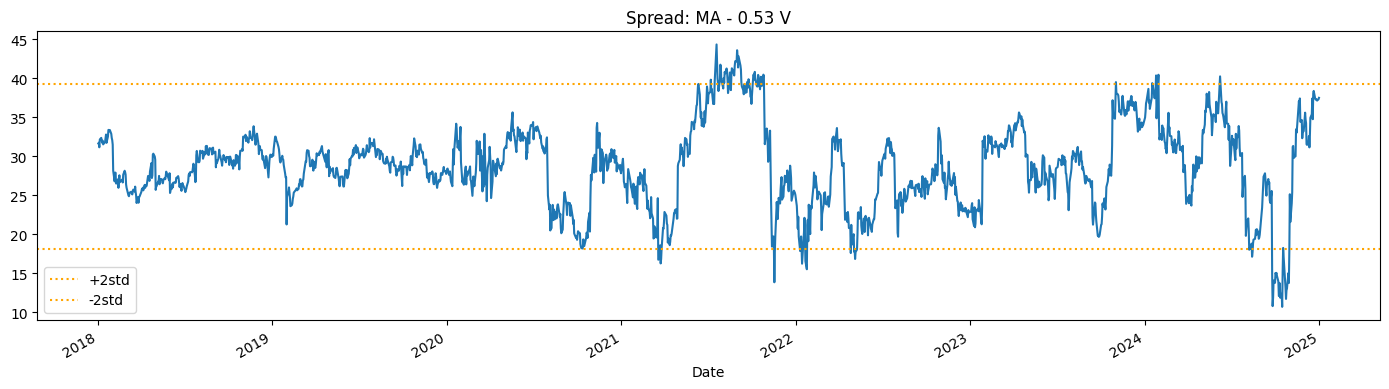

In [41]:
spread = y - beta * x
plt.figure(figsize=(14, 4))
spread.plot()
plt.axhline(spread.mean() + 2*spread.std(), color='orange', linestyle=':', label='+2std')
plt.axhline(spread.mean() - 2*spread.std(), color='orange', linestyle=':', label='-2std')
plt.title(f'Spread: {t1} - {beta.item():.2f} {t2}')
plt.legend()
plt.tight_layout()
plt.show()

  BOLLINGER PAIRS STRATEGY  (V/MA)
  window=30  entry=2.0  β=0.5283
  Total Return   :    -10.46%
  Annual Return  :     -1.57%
  Sharpe Ratio   :    -0.1824
  Max Drawdown   :    -23.92%


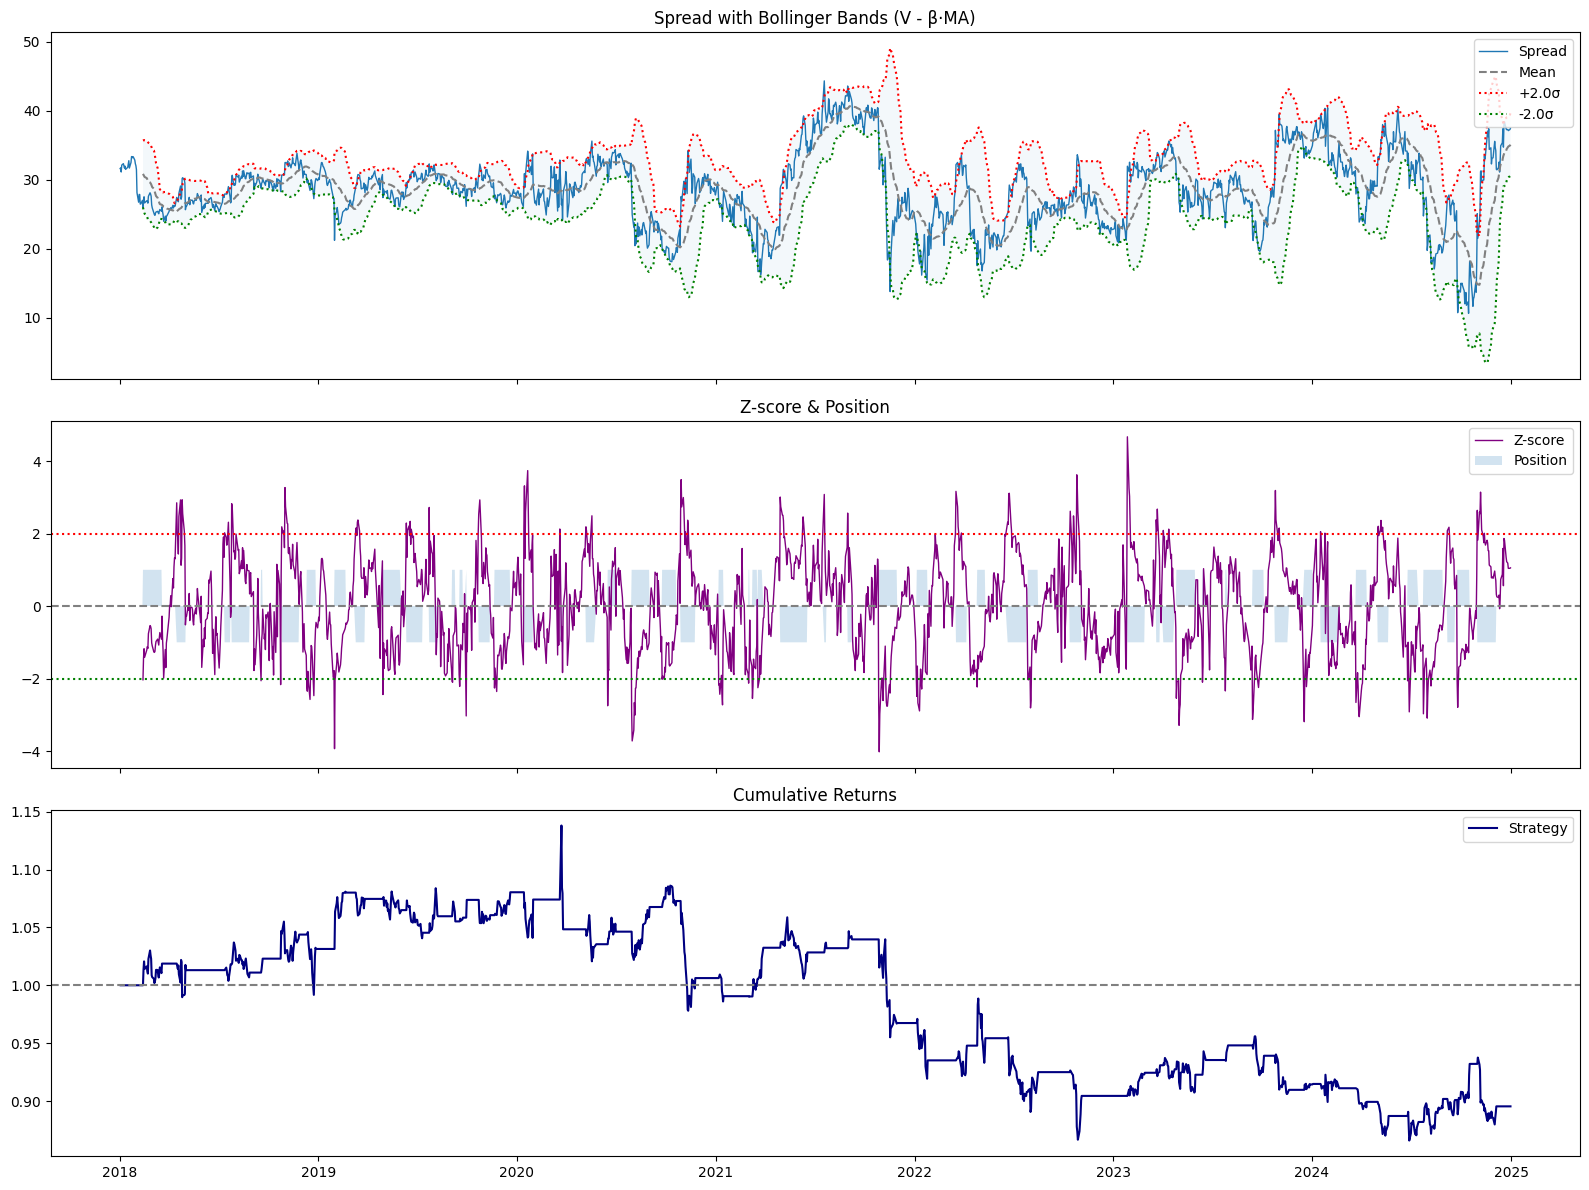

In [65]:
def bollinger_pairs_strat(sa, sb, name_a, name_b, window=30, entry=2.0, exit=0.5):

    # calculate static hedge ratio using OLS
    x_with_const = sm.add_constant(sb)
    static_hedge_model = sm.OLS(sa, x_with_const).fit()
    intercept, beta = static_hedge_model.params.iloc[0], static_hedge_model.params.iloc[1]
    spread = sa - beta * sb

    # bands
    roll = spread.rolling(window)
    roll_mean = roll.mean()
    roll_std = roll.std()
    spread_upper = roll_mean + entry * roll_std
    spread_lower = roll_mean - entry * roll_std
    zscore = (spread - roll_mean) / roll_std

    signals = pd.DataFrame(index=spread.index)
    signals['spread']    = spread
    signals['mean']      = roll_mean
    signals['upper']     = spread_upper
    signals['lower']     = spread_lower
    signals['zscore']    = zscore
    signals['position']  = np.nan

    signals.loc[zscore > entry, 'position'] = -1    # short spread
    signals.loc[zscore < -entry, 'position'] = 1    # long spread
    signals.loc[zscore.abs() < exit, 'position'] = 0 # exit

    signals['position'] = (signals['position']
                        .ffill()
                        .fillna(0))

    # signals['position'].reset_index().plot(x='Date', y='position')
    # plt.show()

    # returns

    # legwise log returns
    ret_a = np.log(sa / sa.shift(1))
    ret_b = np.log(sb / sb.shift(1))

    signals['strategy'] = signals['position'].shift(1) * (ret_a - beta * ret_b)
    signals['log_cumret']   = signals['strategy'].cumsum()
    signals['cumret_scaled'] = np.exp(signals['log_cumret'])

    total_return = signals['cumret_scaled'].iloc[-1] - 1
    annual_ret = np.exp(signals['strategy'].mean() * 252) - 1
    sharpe       = (signals['strategy'].mean() / signals['strategy'].std()) * np.sqrt(252)
    max_dd       = (signals['cumret_scaled'] / signals['cumret_scaled'].cummax() - 1).min()
    
    sep = "=" * 50
    print(sep)
    print(f"  BOLLINGER PAIRS STRATEGY  ({name_a}/{name_b})")
    print(f"  window={window}  entry={entry}  β={beta:.4f}")
    print(sep)
    print(f"  Total Return   : {total_return:>10.2%}")
    print(f"  Annual Return  : {annual_ret:>10.2%}")
    print(f"  Sharpe Ratio   : {sharpe:>10.4f}")
    print(f"  Max Drawdown   : {max_dd:>10.2%}")
    print(sep)

    # --- Plot ---
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    # Spread + bands
    axes[0].plot(signals['spread'], label='Spread', linewidth=1)
    axes[0].plot(signals['mean'],  label='Mean',  linestyle='--', color='gray')
    axes[0].plot(signals['upper'], label=f'+{entry}σ', linestyle=':', color='red')
    axes[0].plot(signals['lower'], label=f'-{entry}σ', linestyle=':', color='green')
    axes[0].fill_between(signals.index, signals['upper'], signals['lower'], alpha=0.05)
    axes[0].set_title(f'Spread with Bollinger Bands ({name_a} - β·{name_b})')
    axes[0].legend(loc='upper right')

    # Z-score + position
    axes[1].plot(signals['zscore'], label='Z-score', color='purple', linewidth=1)
    axes[1].axhline( entry, color='red',   linestyle=':')
    axes[1].axhline(-entry, color='green', linestyle=':')
    axes[1].axhline(0,        color='gray',  linestyle='--')
    axes[1].fill_between(signals.index, signals['position'], 0, alpha=0.2, label='Position')
    axes[1].set_title('Z-score & Position')
    axes[1].legend(loc='upper right')

    # Cumulative returns
    axes[2].plot(signals['cumret_scaled'], label='Strategy', color='navy', linewidth=1.5)
    axes[2].axhline(1, color='gray', linestyle='--')
    axes[2].set_title('Cumulative Returns')
    axes[2].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    return signals

signals = bollinger_pairs_strat(y, x, 'V', 'MA')
    